In [ ]:
!pip install gym numpy matplotlib seaborn hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.3 MB/s eta 0:00:00


2 — Import Libraries

In [ ]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

3 — Create Environment

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=True, disable_env_checker=True)

state_size = env.observation_space.n
action_size = env.action_space.n

print("States:", state_size)
print("Actions:", action_size)

States: 16
Actions: 4


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


4 — Initialize Q-Table

In [ ]:
Q = np.zeros((state_size, action_size))
print(Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


5 — Set Hyperparameters

In [ ]:
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 2000
rewards = []

6 — Training Loop

In [ ]:
for episode in range(episodes):

    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]

    total_reward = 0

    for step in range(100):

        # ε-greedy strategy
        if np.random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state,:])

        step_result = env.step(action)

        if len(step_result) == 5:
            next_state, reward, done, truncated, _ = step_result
            done = done or truncated
        else:
            next_state, reward, done, _ = step_result

        # Q-learning update
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state, :]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards.append(total_reward)

print("Training Completed!")

Training Completed!


7 — Rewards Graph

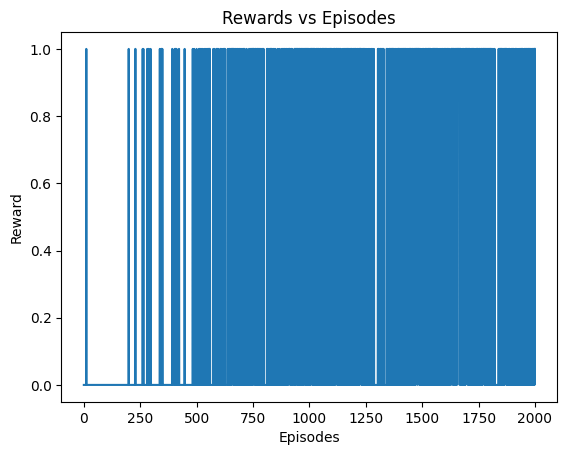

In [ ]:
plt.plot(rewards)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Rewards vs Episodes")
plt.show()

8 — Q-Table Heatmap

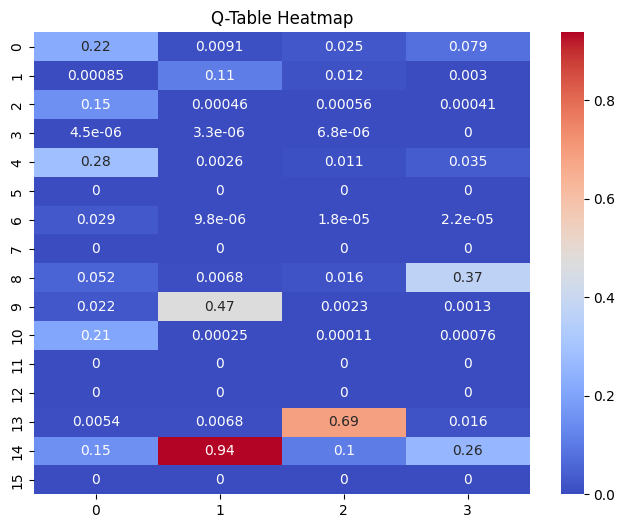

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(Q, annot=True, cmap="coolwarm")
plt.title("Q-Table Heatmap")
plt.show()

9 — Evaluation (Success Rate)

In [ ]:
test_episodes = 100
success = 0

for _ in range(test_episodes):

    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]

    for step in range(100):

        action = np.argmax(Q[state,:])

        step_result = env.step(action)

        if len(step_result) == 5:
            next_state, reward, done, truncated, _ = step_result
            done = done or truncated
        else:
            next_state, reward, done, _ = step_result

        state = next_state

        if done:
            if reward == 1:
                success += 1
            break

print("Success Rate:", success/test_episodes)

Success Rate: 0.77


10 — Policy Visualization

In [ ]:
policy = np.argmax(Q, axis=1)
print("Learned Policy (4x4 grid):")
print(policy.reshape(4,4))

Learned Policy (4x4 grid):
[[0 1 0 2]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]


The learned policy represents the optimal action to take in each state.
It is derived from the Q-table by selecting the action with the highest Q-value.

“The trained Q-learning agent achieved a success rate of 77%, indicating that it has learned a near-optimal policy but still exhibits some stochastic failures due to the slippery nature of the environment.”

# Hidden Markov Model (HMM)

11 — Install Library

In [ ]:
!pip install hmmlearn

12 — Import + Datase

In [ ]:
import numpy as np
from hmmlearn import hmm

observations = np.array([
    [0],[1],[0],[1],[1],[0],[0],
    [1],[1],[0],[1],[0],[0],[1],
    [0],[1],[1],[0],[1],[0]
])

13 — Train Model

In [ ]:
model = hmm.MultinomialHMM(n_components=2, n_iter=200)
model.n_features = 2

# Transform observations into count vectors
# If observations are [0], [1], [0], ..., and n_features=2
# [0] -> [1, 0]
# [1] -> [0, 1]
processed_observations = np.zeros((observations.shape[0], model.n_features), dtype=int)
for i in range(observations.shape[0]):
    symbol = observations[i, 0]
    if 0 <= symbol < model.n_features:
        processed_observations[i, symbol] = 1

model.fit(processed_observations)

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MultinomialHMM(n_components=2, n_iter=200,
               n_trials=array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
               random_state=RandomState(MT19937) at 0x7F7B5E336440)

14 — Results

In [ ]:
print("Transition Matrix:\n", model.transmat_)
print("Emission Matrix:\n", model.emissionprob_)

hidden_states = model.predict(processed_observations)
print("Hidden States:", hidden_states)

log_prob = model.score(processed_observations)
print("Log Likelihood:", log_prob)

Transition Matrix:
 [[2.24443758e-26 1.00000000e+00]
 [1.68092239e-04 9.99831908e-01]]
Emission Matrix:
 [[1.00000000e+00 4.62455970e-24]
 [4.73719088e-01 5.26280912e-01]]
Hidden States: [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Log Likelihood: -13.145558778471775


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


15— Log Likelihood

In [ ]:
print("Log Likelihood of sequence:", model.score(processed_observations))

Log Likelihood of sequence: -13.145558778471775


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


15 — Hidden State Plot

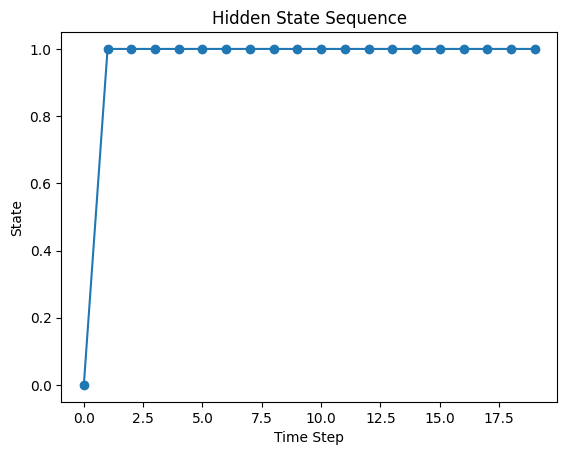

In [ ]:
import matplotlib.pyplot as plt

plt.plot(hidden_states, marker='o')
plt.title("Hidden State Sequence")
plt.xlabel("Time Step")
plt.ylabel("State")
plt.show()